In [7]:
!pip install datasets -q

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

print("Yamini.M")
print("24BAD131")
path = tf.keras.utils.get_file(
    "shakespeare.txt",
    "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt"
)

with open(path, "r", encoding="utf-8") as file:
    text = file.read().lower()

print("TEXT SAMPLE:\n")
print(text[:500])

tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1

print("\nVocabulary Size:", total_words)

input_sequences = []

for line in text.split("\n"):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        sequence = token_list[:i + 1]
        input_sequences.append(sequence)

max_sequence_len = max(
    len(sequence) for sequence in input_sequences
)
input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_sequence_len,
    padding="pre"
)
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nMaximum Sequence Length:", max_sequence_len)
print("X_train Shape:", X_train.shape)
print("X_val Shape:", X_val.shape)
print("y_train Shape:", y_train.shape)
print("y_val Shape:", y_val.shape)

Yamini.M
24BAD131
TEXT SAMPLE:

first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor

Vocabulary Size: 12633

Maximum Sequence Length: 16
X_train Shape: (137049, 15)
X_val Shape: (34263, 15)
y_train Shape: (137049,)
y_val Shape: (34263,)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

print("Yamini.M")
print("24BAD131")

model = Sequential([
    Embedding(
        input_dim=total_words,
        output_dim=64,
        input_length=max_sequence_len - 1
    ),

    SimpleRNN(128),

    Dense(
        total_words,
        activation="softmax"
    )
])
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Yamini.M
24BAD131


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Yamini.M
24BAD131
Epoch 1/3
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 68s 63ms/step - accuracy: 0.0466 - loss: 6.7982 - val_accuracy: 0.0709 - val_loss: 6.4393
Epoch 2/3
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 66s 62ms/step - accuracy: 0.0848 - loss: 6.1294 - val_accuracy: 0.0911 - val_loss: 6.2715
Epoch 3/3
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 64s 60ms/step - accuracy: 0.0999 - loss: 5.7898 - val_accuracy: 0.0964 - val_loss: 6.2308

FINAL PERFORMANCE RESULTS
-----------------------------------
Training Accuracy: 9.99 %
Validation Accuracy: 9.64 %
Training Loss: 5.7898
Validation Loss: 6.2308


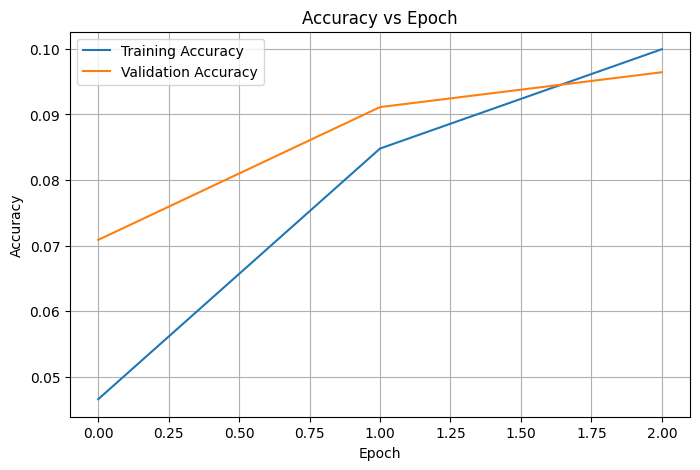

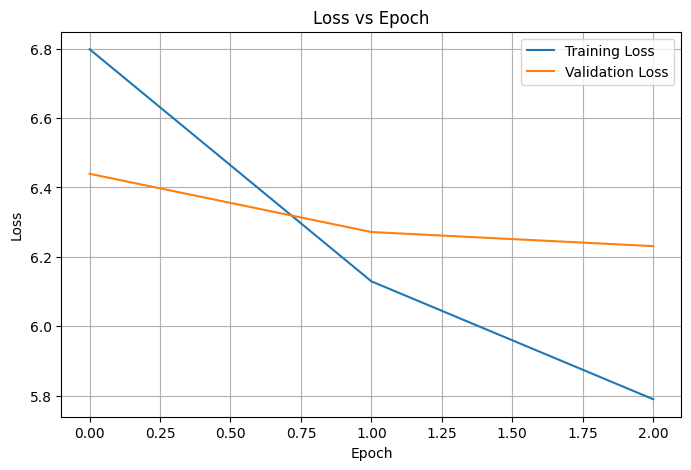

In [9]:
import matplotlib.pyplot as plt

print("Yamini.M")
print("24BAD131")
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=3,
    batch_size=128
)
print("\nFINAL PERFORMANCE RESULTS")
print("-" * 35)
print(
    "Training Accuracy:",
    round(history.history["accuracy"][-1] * 100, 2),
    "%"
)
print(
    "Validation Accuracy:",
    round(history.history["val_accuracy"][-1] * 100, 2),
    "%"
)
print(
    "Training Loss:",
    round(history.history["loss"][-1], 4)
)
print(
    "Validation Loss:",
    round(history.history["val_loss"][-1], 4)
)
plt.figure(figsize=(8, 5))
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()
plt.figure(figsize=(8, 5))
plt.plot(
    history.history["loss"],
    label="Training Loss"
)
plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [11]:
print("Yamini.M")
print("24BAD131")
def generate_text(seed_text, next_words=20):

    generated_text = seed_text.lower()

    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences(
            [generated_text]
        )[0]
        token_list = pad_sequences(
            [token_list],
            maxlen=max_sequence_len - 1,
            padding="pre"
        )
        predicted = model.predict(
            token_list,
            verbose=0
        )

        predicted_word_index = np.argmax(predicted)
        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_word_index:
                output_word = word
                break

        generated_text += " " + output_word

    return generated_text

seed_1 = "to be"
seed_2 = "the king"
seed_3 = "i love"

print("GENERATED TEXT SAMPLE 1")
print("-" * 40)
print(generate_text(seed_1, 20))

print("\nGENERATED TEXT SAMPLE 2")
print("-" * 40)
print(generate_text(seed_2, 20))

print("\nGENERATED TEXT SAMPLE 3")
print("-" * 40)
print(generate_text(seed_3, 20))

Yamini.M
24BAD131
GENERATED TEXT SAMPLE 1
----------------------------------------
to be a man of the king of york and i have done to the king henry vi and all the king

GENERATED TEXT SAMPLE 2
----------------------------------------
the king is not to the king of york and i have done to the king of york and i have done

GENERATED TEXT SAMPLE 3
----------------------------------------
i love my lord i am a man of the king of york and i have done to the king of york
